# Data Quality Diagnostics

**Docker image**: `ml4t`

**Chapter 7: Defining the Learning Task**
**Section Reference**: 7.1 - Data Preprocessing and Encodings

## Purpose

This notebook provides a **standardized diagnostic survey** across all ML4T datasets.
No cleaning is performed—just assessment. The output is a "health report" identifying
which datasets need active preprocessing versus which are already in good shape.

## Learning Objectives

1. Build reusable diagnostic functions for financial panel data
2. Understand common data quality issues: missingness, duplicates, outliers, gaps
3. Identify dataset-specific quirks that affect ML pipeline design
4. Create a systematic framework for data validation

## Book Reference

Section 7.1 emphasizes that **data quality determines model quality**. This notebook
operationalizes that principle with concrete diagnostics before any feature engineering.

## Prerequisites

- Familiarity with the seven ML4T datasets and their loaders (`data` module).
- Polars basics (`pl.DataFrame`, `group_by`, `with_columns`).
- No prior notebook output is required; this is the entry point of the pipeline.

## Data Contract

- **Input**: Raw datasets from data loaders (ETFs, US Equities, Crypto, etc.)
- **Output**: Diagnostic reports and quality assessments (no mutations)

In [1]:
"""Data Quality Diagnostics - Survey all ML4T datasets."""

from __future__ import annotations

import logging
import warnings
from datetime import datetime
from typing import Any

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import display

from data import (
    load_cme_futures,
    load_crypto_perps,
    load_crypto_premium,
    load_etfs,
    load_firm_characteristics,
    load_fx_pairs,
    load_us_equities,
)

warnings.filterwarnings("ignore")
# Suppress chatty INFO logs from ml4t.diagnostic so output cells stay focused on results.
logging.disable(logging.INFO)

In [2]:
# Production defaults
ETF_START_DATE = "2015-01-01"
US_EQUITIES_START_DATE = "1970-01-01"
CRYPTO_START_DATE = "2021-01-01T00:00:00+00:00"
CME_FUTURES_START_DATE = "2015-01-01"
FX_START_DATE = "2015-01-01T00:00:00+00:00"
FIRM_CHARACTERISTICS_START_DATE = "1990-01-01"

## 1. Diagnostic Function Library

These functions are designed to be **reusable** across datasets and chapters.
They follow a consistent interface: input DataFrame, return diagnostic results.

### 1.1 Index Integrity Check

Validates that the time index has correct dtype, monotonicity, and uniqueness.
For panel data, also checks that (date, symbol) pairs are unique.

In [3]:
def check_index_integrity(
    df: pl.DataFrame,
    time_col: str = "timestamp",
    symbol_col: str | None = "symbol",
) -> dict[str, Any]:
    """Check index integrity: dtype, monotonicity, uniqueness.

    Args:
        df: Input DataFrame
        time_col: Name of the time column
        symbol_col: Name of the symbol column (None for single-asset data)

    Returns:
        Dictionary with diagnostic results
    """
    results = {
        "time_col": time_col,
        "symbol_col": symbol_col,
        "n_rows": len(df),
        "checks": {},
    }

    # Check time column dtype
    time_dtype = df[time_col].dtype
    results["time_dtype"] = str(time_dtype)
    results["checks"]["valid_time_dtype"] = time_dtype in [pl.Date, pl.Datetime]

    # Check for null time values
    null_times = df[time_col].is_null().sum()
    results["null_times"] = null_times
    results["checks"]["no_null_times"] = null_times == 0

    if symbol_col and symbol_col in df.columns:
        # Panel data: check uniqueness of (date, symbol)
        n_unique = df.select([time_col, symbol_col]).unique().height
        results["unique_pairs"] = n_unique
        results["checks"]["unique_date_symbol"] = n_unique == len(df)

        # Check monotonicity within each symbol
        sorted_df = df.sort([symbol_col, time_col])
        mono_check = sorted_df.group_by(symbol_col).agg(
            is_mono=(pl.col(time_col) == pl.col(time_col).sort()).all()
        )
        all_mono = mono_check["is_mono"].all()
        results["checks"]["monotonic_per_symbol"] = all_mono

        # Symbol statistics
        n_symbols = df[symbol_col].n_unique()
        results["n_symbols"] = n_symbols
    else:
        # Single asset: check global monotonicity
        is_sorted = (df[time_col] == df[time_col].sort()).all()
        results["checks"]["monotonic"] = is_sorted

        # Check uniqueness
        n_unique = df[time_col].n_unique()
        results["unique_times"] = n_unique
        results["checks"]["unique_times"] = n_unique == len(df)

    # Date range
    results["date_min"] = str(df[time_col].min())
    results["date_max"] = str(df[time_col].max())

    # Overall pass/fail
    results["passed"] = all(results["checks"].values())

    return results

### 1.2 Duplicate Detection

Finds exact duplicates (identical rows) and near-duplicates (same index, different values).

In [4]:
def check_duplicates(
    df: pl.DataFrame,
    key_cols: list[str],
    value_cols: list[str] | None = None,
) -> dict[str, Any]:
    """Detect exact and near-duplicates.

    Args:
        df: Input DataFrame
        key_cols: Columns that define uniqueness (e.g., ['timestamp', 'symbol'])
        value_cols: Columns to check for value differences in near-duplicates

    Returns:
        Dictionary with duplicate counts and examples
    """
    results = {"key_cols": key_cols, "n_rows": len(df)}

    # Exact duplicates (all columns identical)
    n_exact = len(df) - df.unique().height
    results["exact_duplicates"] = n_exact

    # Key duplicates (same key, potentially different values)
    key_counts = df.group_by(key_cols).len()
    dupes = key_counts.filter(pl.col("len") > 1)
    n_key_dupes = dupes["len"].sum() - len(dupes) if len(dupes) > 0 else 0
    results["key_duplicates"] = n_key_dupes

    # If there are key duplicates and value columns specified, check for near-dupes
    if n_key_dupes > 0 and value_cols:
        # Near-duplicates: same key, different values
        dupe_keys = dupes.select(key_cols)
        dupe_rows = df.join(dupe_keys, on=key_cols, how="inner")

        # Group by key and check if values vary
        near_dupes = dupe_rows.group_by(key_cols).agg(
            [pl.col(c).n_unique().alias(f"{c}_nunique") for c in value_cols]
        )
        # Count rows where any value column has more than 1 unique value
        vary_cols = [f"{c}_nunique" for c in value_cols]
        has_variation = near_dupes.select([(pl.col(c) > 1) for c in vary_cols]).select(
            pl.any_horizontal(pl.all())
        )

        n_near = has_variation.sum().item() if len(has_variation) > 0 else 0
        results["near_duplicates"] = n_near

        # Sample of duplicates
        if n_key_dupes > 0 and len(dupe_rows) > 0:
            results["sample_duplicates"] = dupe_rows.head(5).to_dicts()
    else:
        results["near_duplicates"] = 0

    results["passed"] = n_exact == 0 and n_key_dupes == 0

    return results

### 1.3 Coverage Report

Analyzes missingness patterns by field, by asset, and by time period.

In [5]:
def coverage_report(
    df: pl.DataFrame,
    time_col: str = "timestamp",
    symbol_col: str | None = "symbol",
    value_cols: list[str] | None = None,
) -> dict[str, Any]:
    """Generate coverage report: missingness by field, asset, time.

    Args:
        df: Input DataFrame
        time_col: Time column name
        symbol_col: Symbol column name (None for single-asset)
        value_cols: Columns to check for missingness (default: numeric columns)

    Returns:
        Dictionary with coverage statistics
    """
    results = {"n_rows": len(df), "n_cols": len(df.columns)}

    # Default to numeric columns if not specified
    if value_cols is None:
        value_cols = [
            c
            for c in df.columns
            if df[c].dtype in [pl.Float32, pl.Float64, pl.Int32, pl.Int64]
            and c not in [time_col, symbol_col]
        ]

    results["checked_cols"] = value_cols

    # Missingness by column
    col_missing = {}
    for col in value_cols:
        n_null = df[col].is_null().sum()
        pct_null = 100.0 * n_null / len(df) if len(df) > 0 else 0
        col_missing[col] = {"n_null": n_null, "pct_null": round(pct_null, 2)}

    results["by_column"] = col_missing

    # Worst columns
    sorted_cols = sorted(col_missing.items(), key=lambda x: x[1]["pct_null"], reverse=True)
    results["worst_columns"] = sorted_cols[:5]

    # Missingness by asset (if panel)
    if symbol_col and symbol_col in df.columns:
        # For each symbol, count rows with any missing value
        symbol_missing = df.group_by(symbol_col).agg(
            [
                pl.len().alias("n_rows"),
                *[pl.col(c).is_null().sum().alias(f"{c}_null") for c in value_cols[:5]],
            ]
        )
        results["n_symbols"] = df[symbol_col].n_unique()

        # Find symbols with most missing data
        null_cols = [f"{c}_null" for c in value_cols[:5]]
        if null_cols:
            symbol_missing = symbol_missing.with_columns(
                total_null=pl.sum_horizontal(null_cols)
            ).sort("total_null", descending=True)
            results["worst_symbols"] = symbol_missing.head(5).to_dicts()

    # Missingness by time period
    time_missing = df.group_by(time_col).agg(
        [pl.col(c).is_null().sum().alias(f"{c}_null") for c in value_cols[:3]]
    )
    if value_cols:
        null_col = f"{value_cols[0]}_null"
        worst_dates = time_missing.sort(null_col, descending=True).head(5)
        results["worst_dates"] = worst_dates.to_dicts()

    # Overall coverage
    total_cells = len(df) * len(value_cols)
    total_missing = sum(v["n_null"] for v in col_missing.values())
    results["overall_coverage_pct"] = (
        round(100 * (1 - total_missing / total_cells), 2) if total_cells > 0 else 100
    )

    return results

### 1.4 Coverage Heatmap

Visualizes data availability across time × asset for panel data.

In [6]:
def coverage_heatmap(
    df: pl.DataFrame,
    time_col: str = "timestamp",
    symbol_col: str = "symbol",
    value_col: str = "close",
    title: str = "Data Coverage Heatmap",
    max_symbols: int = 50,
) -> go.Figure:
    """Create time × asset coverage heatmap.

    Args:
        df: Input DataFrame
        time_col: Time column name
        symbol_col: Symbol column name
        value_col: Column to check for presence
        title: Plot title
        max_symbols: Maximum symbols to show (for readability)

    Returns:
        Plotly figure
    """
    # Aggregate to reduce data size - use monthly periods
    coverage_df = (
        df.with_columns(period=pl.col(time_col).dt.truncate("1mo"))
        .group_by(["period", symbol_col])
        .agg(has_data=(pl.col(value_col).is_not_null().sum() > 0).cast(pl.Int8))
    )

    # Pivot to matrix
    symbols = coverage_df[symbol_col].unique().sort().to_list()
    if len(symbols) > max_symbols:
        # Sample symbols for readability
        symbols = symbols[:: len(symbols) // max_symbols][:max_symbols]
        coverage_df = coverage_df.filter(pl.col(symbol_col).is_in(symbols))

    pivot_df = coverage_df.pivot(
        values="has_data",
        index="period",
        on=symbol_col,
    ).sort("period")

    # Extract matrix
    periods = pivot_df["period"].to_list()
    period_labels = [str(p)[:7] for p in periods]  # YYYY-MM format
    matrix = pivot_df.drop("period").to_numpy()

    # Create heatmap
    fig = go.Figure(
        data=go.Heatmap(
            z=matrix,
            x=symbols,
            y=period_labels,
            colorscale=[[0, "#2166ac"], [1, "#f7f7f7"]],  # Blue=missing, White=present
            showscale=False,
            hovertemplate="Symbol: %{x}<br>Period: %{y}<br>Has data: %{z}<extra></extra>",
        )
    )

    fig.update_layout(
        title=title,
        xaxis_title="Symbol",
        yaxis_title="Period",
        height=max(400, len(periods) * 15),
        width=max(600, len(symbols) * 15),
    )

    return fig

### 1.5 Distribution Summary

Computes summary statistics and flags extreme values.

In [7]:
def distribution_summary(
    df: pl.DataFrame,
    fields: list[str],
    extreme_threshold: float = 5.0,
) -> pl.DataFrame:
    """Compute distribution statistics with extreme value flags.

    Args:
        df: Input DataFrame
        fields: Columns to summarize
        extreme_threshold: Z-score threshold for flagging extremes

    Returns:
        DataFrame with summary statistics
    """
    stats_list = []

    for field in fields:
        if field not in df.columns:
            continue

        col = df[field].drop_nulls()
        if len(col) == 0:
            continue

        # Basic stats
        stats = {
            "field": field,
            "count": len(col),
            "null_pct": round(100 * df[field].is_null().sum() / len(df), 2),
            "mean": round(col.mean(), 6),
            "std": round(col.std(), 6),
            "min": round(col.min(), 6),
            "q25": round(col.quantile(0.25), 6),
            "median": round(col.median(), 6),
            "q75": round(col.quantile(0.75), 6),
            "max": round(col.max(), 6),
        }

        # Skewness and kurtosis (using numpy for robustness)
        arr = col.to_numpy()
        if len(arr) > 2 and np.std(arr) > 0:
            stats["skew"] = round(float(np.mean(((arr - np.mean(arr)) / np.std(arr)) ** 3)), 4)
            stats["kurtosis"] = round(
                float(np.mean(((arr - np.mean(arr)) / np.std(arr)) ** 4) - 3), 4
            )
        else:
            stats["skew"] = 0.0
            stats["kurtosis"] = 0.0

        # Extreme value count
        if stats["std"] > 0:
            z_scores = np.abs((arr - np.mean(arr)) / np.std(arr))
            n_extreme = int(np.sum(z_scores > extreme_threshold))
            stats["n_extreme"] = n_extreme
            stats["pct_extreme"] = round(100 * n_extreme / len(arr), 4)
        else:
            stats["n_extreme"] = 0
            stats["pct_extreme"] = 0.0

        stats_list.append(stats)

    return pl.DataFrame(stats_list)

### 1.6 Outlier Flags

Detects domain violations and spike anomalies (single-bar reversals).

In [8]:
def outlier_flags(
    df: pl.DataFrame,
    price_cols: list[str] | None = None,
    volume_col: str | None = "volume",
    return_col: str | None = None,
    max_return_threshold: float = 2.0,
) -> dict[str, Any]:
    """Flag domain violations and spike anomalies.

    Args:
        df: Input DataFrame
        price_cols: Price columns to check for domain violations
        volume_col: Volume column to check for negative values
        return_col: Return column to check for extreme spikes
        max_return_threshold: Maximum plausible return (e.g., 2.0 = 200%)

    Returns:
        Dictionary with outlier counts and examples
    """
    results = {"n_rows": len(df), "flags": {}}

    # Check for negative prices
    if price_cols:
        for col in price_cols:
            if col in df.columns:
                n_negative = (df[col] < 0).sum()
                n_zero = (df[col] == 0).sum()
                results["flags"][f"{col}_negative"] = n_negative
                results["flags"][f"{col}_zero"] = n_zero

    # Check for negative volume
    if volume_col and volume_col in df.columns:
        n_neg_vol = (df[volume_col] < 0).sum()
        results["flags"]["negative_volume"] = n_neg_vol

    # Check for impossible returns
    if return_col and return_col in df.columns:
        impossible = df[return_col].abs() > max_return_threshold
        n_impossible = impossible.sum()
        results["flags"]["impossible_returns"] = n_impossible

        if n_impossible > 0:
            examples = df.filter(impossible).head(5)
            results["impossible_return_examples"] = examples.to_dicts()

    # Spike detection: single-bar reversals
    # A spike is when price moves sharply then reverts (e.g., OHLC where H > 2*C or L < C/2).
    # Resolve the high/low/close names so roll-adjusted panels (adj_*) are covered too;
    # the spike ratio is adjust-invariant (all OHLC in a bar share one adjustment factor).
    def _resolve(*names: str) -> str | None:
        return next((n for n in names if n in df.columns), None)

    hi_col = _resolve("high", "adj_high")
    lo_col = _resolve("low", "adj_low")
    cl_col = _resolve("close", "adj_close")
    if hi_col and lo_col and cl_col:
        # Detect bars where high is >50% above close
        high_spike = df[hi_col] > df[cl_col] * 1.5
        low_spike = df[lo_col] < df[cl_col] * 0.5
        n_spikes = (high_spike | low_spike).sum()
        results["flags"]["price_spikes"] = n_spikes

    # Count total flags
    results["total_flags"] = sum(results["flags"].values())
    results["passed"] = results["total_flags"] == 0

    return results

### 1.7 Calendar Gap Check

Compares observed trading dates against expected calendar.

In [9]:
def calendar_gap_check(
    df: pl.DataFrame,
    time_col: str = "timestamp",
    symbol_col: str | None = "symbol",
    expected_freq: str = "1d",
    exclude_weekends: bool = True,
) -> dict[str, Any]:
    """Check for unexpected gaps in time series.

    Args:
        df: Input DataFrame
        time_col: Time column name
        symbol_col: Symbol column (checks gaps per symbol if provided)
        expected_freq: Expected frequency ('1d', '1h', '8h', etc.)
        exclude_weekends: If True, weekend gaps are expected (for daily data)

    Returns:
        Dictionary with gap analysis
    """
    results = {"expected_freq": expected_freq, "gaps": []}

    if symbol_col and symbol_col in df.columns:
        # Analyze gaps per symbol
        symbols = df[symbol_col].unique().to_list()
        gap_counts = []

        for sym in symbols[:20]:  # Limit for performance
            sym_df = df.filter(pl.col(symbol_col) == sym).sort(time_col)
            gaps = _find_gaps(sym_df, time_col, expected_freq, exclude_weekends)
            gap_counts.append({"symbol": sym, "n_gaps": len(gaps)})

        results["gap_counts"] = gap_counts
        total_gaps = sum(g["n_gaps"] for g in gap_counts)
        results["total_gaps"] = total_gaps
    else:
        # Single time series
        sorted_df = df.sort(time_col)
        gaps = _find_gaps(sorted_df, time_col, expected_freq, exclude_weekends)
        results["gaps"] = gaps[:10]  # First 10 gaps
        results["total_gaps"] = len(gaps)

    results["passed"] = results["total_gaps"] == 0

    return results

#### Gap Detection Helper
Identify unexpected gaps between consecutive timestamps in a sorted series.

In [10]:
def _find_gaps(
    df: pl.DataFrame,
    time_col: str,
    expected_freq: str,
    exclude_weekends: bool,
) -> list[dict]:
    """Find gaps in a sorted time series."""
    gaps = []

    times = df[time_col].to_list()
    if len(times) < 2:
        return gaps

    # Parse expected frequency
    freq_map = {"1d": 1, "1h": 1 / 24, "4h": 4 / 24, "8h": 8 / 24}
    expected_days = freq_map.get(expected_freq, 1)

    for i in range(1, len(times)):
        prev = times[i - 1]
        curr = times[i]

        if hasattr(prev, "timestamp"):
            delta_days = (curr - prev).total_seconds() / 86400
        else:
            delta_days = (curr - prev).days

        # Adjust for weekends
        if exclude_weekends and expected_freq == "1d":
            if hasattr(prev, "weekday"):
                weekday = prev.weekday()
            else:
                weekday = prev.day_of_week().to_physical()
            if weekday == 4:  # Friday
                expected_days = 3
            else:
                expected_days = 1

        if delta_days > expected_days * 1.5:  # Allow 50% tolerance
            gaps.append(
                {
                    "from": str(prev),
                    "to": str(curr),
                    "gap_days": round(delta_days, 2),
                }
            )

    return gaps

## 2. Dataset Registry

Central registry mapping dataset names to loader functions and metadata.

In [11]:
def load_dataset_safely(loader_func, *args, **kwargs):
    """Attempt to load a dataset, returning None with message if unavailable."""
    try:
        return loader_func(*args, **kwargs)
    except Exception as e:
        error_type = type(e).__name__
        print(f"  WARNING: Could not load: {error_type}")
        return None


# Define dataset registry
DATASET_REGISTRY = {
    "etfs": {
        "loader": load_etfs,
        "time_col": "timestamp",
        "symbol_col": "symbol",
        "freq": "daily",
        "price_cols": ["open", "high", "low", "close"],
        "volume_col": "volume",
        "description": "100 ETFs from Yahoo Finance",
    },
    "us_equities": {
        "loader": load_us_equities,
        "time_col": "timestamp",
        "symbol_col": "symbol",
        "freq": "daily",
        "price_cols": ["open", "high", "low", "close", "adj_close"],
        "volume_col": "volume",
        "description": "3,199 US equities (1962-2018)",
    },
    "crypto_perps": {
        "loader": lambda: load_crypto_perps(frequency="8h"),
        "time_col": "timestamp",
        "symbol_col": "symbol",
        "freq": "8h",
        "price_cols": ["open", "high", "low", "close"],
        "volume_col": "volume",
        "description": "Crypto perpetuals from Binance",
    },
    "crypto_premium": {
        "loader": lambda: load_crypto_premium(frequency="8h"),
        "time_col": "timestamp",
        "symbol_col": "symbol",
        "freq": "8h",
        "price_cols": [
            "premium_index_open",
            "premium_index_high",
            "premium_index_low",
            "premium_index_close",
        ],
        "volume_col": None,
        "description": "Crypto premium index from Binance",
    },
    "cme_futures": {
        "loader": lambda: load_cme_futures(tenors=[0]),
        "time_col": "session_date",
        "symbol_col": "product",
        "freq": "daily",
        # Diagnostics run on the adjusted series (the canonical downstream series);
        # per-row OHLC share one cum_ratio, so integrity checks are adjust-invariant.
        "price_cols": ["adj_open", "adj_high", "adj_low", "adj_close"],
        "volume_col": "volume",
        "description": "CME futures (front month)",
    },
    "fx_pairs": {
        "loader": lambda: load_fx_pairs(frequency="4h"),
        "time_col": "timestamp",
        "symbol_col": "symbol",
        "freq": "4h",
        "price_cols": ["open", "high", "low", "close"],
        "volume_col": "volume",
        "description": "FX pairs from OANDA",
    },
    "firm_characteristics": {
        "loader": load_firm_characteristics,
        "time_col": "timestamp",
        "symbol_col": None,
        "freq": "monthly",
        "price_cols": [],
        "volume_col": None,
        "description": "Chen-Pelger-Zhu firm characteristics",
    },
}

## 3. Per-Dataset Diagnostics

Run all diagnostics for each available dataset. Results are stored for the
summary dashboard.

In [12]:
diagnostic_results = {}

In [13]:
def ensure_symbol_alias(df: pl.DataFrame) -> pl.DataFrame:
    """Expose the canonical asset identifier under the symbol name when needed."""
    if "asset" in df.columns and "symbol" not in df.columns:
        return df.with_columns(pl.col("asset").alias("symbol"))
    return df

In [14]:
def filter_from_start(df: pl.DataFrame, time_col: str, start_value: str) -> pl.DataFrame:
    """Apply a start-date filter without tripping over timezone/unit differences."""
    start_date = datetime.fromisoformat(start_value).date()
    dtype = df.schema[time_col]
    if dtype == pl.Date:
        return df.filter(pl.col(time_col) >= pl.lit(start_date).cast(pl.Date))
    return df.filter(pl.col(time_col).dt.date() >= pl.lit(start_date).cast(pl.Date))

### 3.1 ETF Universe

Yahoo Finance data covering 100 ETFs across 9 asset classes. Key concerns:
adjustment artifacts from corporate actions and ticker changes.

In [15]:
etfs = load_dataset_safely(DATASET_REGISTRY["etfs"]["loader"])

if etfs is not None:
    config = DATASET_REGISTRY["etfs"]
    tcol = config["time_col"]
    etfs = ensure_symbol_alias(etfs)
    etfs = filter_from_start(etfs, tcol, ETF_START_DATE)

    print(f"Loaded {len(etfs):,} rows, {etfs['symbol'].n_unique()} symbols")
    print(f"Date range: {etfs[tcol].min()} to {etfs[tcol].max()}")

Loaded 275,536 rows, 100 symbols
Date range: 2015-01-02 to 2025-12-31


In [16]:
if etfs is not None:
    # Index integrity and duplicates
    idx_check = check_index_integrity(etfs, config["time_col"], config["symbol_col"])
    dupe_check = check_duplicates(
        etfs,
        key_cols=[config["time_col"], config["symbol_col"]],
        value_cols=config["price_cols"],
    )
    print(f"Index Integrity: {'PASSED' if idx_check['passed'] else 'FAILED'}")
    print(
        f"Duplicates:      {'PASSED' if dupe_check['passed'] else 'FAILED'} "
        f"(exact: {dupe_check['exact_duplicates']}, key: {dupe_check['key_duplicates']})"
    )

Index Integrity: PASSED
Duplicates:      PASSED (exact: 0, key: 0)


In [17]:
if etfs is not None:
    # Coverage and outlier flags
    cov_report = coverage_report(
        etfs,
        config["time_col"],
        config["symbol_col"],
        config["price_cols"] + [config["volume_col"]],
    )
    outliers = outlier_flags(
        etfs,
        price_cols=config["price_cols"],
        volume_col=config["volume_col"],
    )
    print(f"Coverage: {cov_report['overall_coverage_pct']}%")
    print(f"Outliers: {'PASSED' if outliers['passed'] else 'FLAGGED'}")
    for flag, count in outliers["flags"].items():
        if count > 0:
            print(f"  {flag}: {count}")

Coverage: 100.0%
Outliers: PASSED


In [18]:
if etfs is not None:
    # Distribution summary
    dist_summary = distribution_summary(etfs, config["price_cols"][:3])
    display(dist_summary)

    diagnostic_results["etfs"] = {
        "index": idx_check,
        "duplicates": dupe_check,
        "coverage": cov_report,
        "outliers": outliers,
    }

field,count,null_pct,mean,std,min,q25,median,q75,max,skew,kurtosis,n_extreme,pct_extreme
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""open""",275536,0.0,78.298191,76.831683,7.83,32.993526,59.846203,92.811785,688.758989,3.2654,13.9964,2290,0.8311
"""high""",275536,0.0,78.762509,77.386241,7.99,33.201865,60.153039,93.318535,689.776169,3.2674,13.9924,2295,0.8329
"""low""",275536,0.0,77.797276,76.224877,7.405079,32.776164,59.505112,92.203559,687.392725,3.263,13.998,2284,0.8289


ETFs pass index integrity and duplicate checks. Coverage is near-complete for
OHLCV fields. Any outlier flags likely reflect Yahoo Finance adjustment
artifacts (split ratios applied to historical bars) rather than genuine
price anomalies.

### 3.2 US Equities

Longest dataset (56 years) with survivorship-free panel. Key concerns:
penny stocks, stock splits, and delisting events.

In [19]:
us_equities = load_dataset_safely(DATASET_REGISTRY["us_equities"]["loader"])

if us_equities is not None:
    config = DATASET_REGISTRY["us_equities"]
    us_equities = ensure_symbol_alias(us_equities)
    us_equities = filter_from_start(us_equities, "timestamp", US_EQUITIES_START_DATE)

    print(f"Loaded {len(us_equities):,} rows, {us_equities['symbol'].n_unique()} symbols")
    print(f"Date range: {us_equities['timestamp'].min()} to {us_equities['timestamp'].max()}")

Loaded 15,371,431 rows, 3199 symbols
Date range: 1970-01-02 to 2018-03-27


In [20]:
if us_equities is not None:
    # Index integrity
    idx_check = check_index_integrity(us_equities, config["time_col"], config["symbol_col"])
    print(f"Index Integrity: {'PASSED' if idx_check['passed'] else 'FAILED'}")

    # Duplicates and coverage (same battery as the other panels; this is the
    # largest dataset and the one that most needs the full check).
    dupe_check = check_duplicates(
        us_equities,
        key_cols=[config["time_col"], config["symbol_col"]],
        value_cols=config["price_cols"],
    )
    cov_report = coverage_report(
        us_equities,
        config["time_col"],
        config["symbol_col"],
        config["price_cols"] + [config["volume_col"]],
    )
    print(
        f"Duplicates:      {'PASSED' if dupe_check['passed'] else 'FAILED'} "
        f"(exact: {dupe_check['exact_duplicates']}, key: {dupe_check['key_duplicates']})"
    )
    print(f"Coverage: {cov_report['overall_coverage_pct']}%")

    # Penny stocks and extreme returns
    penny = us_equities.filter(pl.col("close") < 1)
    us_equities_ret = us_equities.sort(["symbol", "timestamp"]).with_columns(
        returns=pl.col("close").pct_change().over("symbol")
    )
    extreme_ret = us_equities_ret.filter(pl.col("returns").abs() > 1.0)
    print(
        f"Penny stocks (close < $1): {len(penny):,} rows ({100 * len(penny) / len(us_equities):.1f}%)"
    )
    print(f"Extreme returns (>100%):   {len(extreme_ret):,} rows")

Index Integrity: PASSED


Duplicates:      PASSED (exact: 0, key: 0)
Coverage: 100.0%


Penny stocks (close < $1): 209,818 rows (1.4%)
Extreme returns (>100%):   837 rows


In [21]:
if us_equities is not None:
    # Outlier flags
    outliers = outlier_flags(
        us_equities,
        price_cols=["open", "high", "low", "close"],
        volume_col="volume",
    )
    print(f"Outliers: {'PASSED' if outliers['passed'] else 'FLAGGED'}")
    for flag, count in outliers["flags"].items():
        if count > 0:
            print(f"  {flag}: {count}")

    diagnostic_results["us_equities"] = {
        "index": idx_check,
        "duplicates": dupe_check,
        "coverage": cov_report,
        "outliers": outliers,
        "penny_stocks": len(penny),
        "extreme_returns": len(extreme_ret),
    }

Outliers: FLAGGED
  price_spikes: 2739


US Equities is the dataset that most needs active cleaning. Penny stocks
($<1) should be filtered to avoid microstructure noise dominating cross-sectional
models. Extreme returns (>100% daily) typically reflect stock splits or
data errors and require investigation. See `02_preprocessing_pipeline`
for the full cleaning pipeline.

### Coverage Heatmap: US Equities

Visualize data availability across time and assets. The staircase pattern
along the edges reflects new listings (lower-left) and delistings (upper-right).

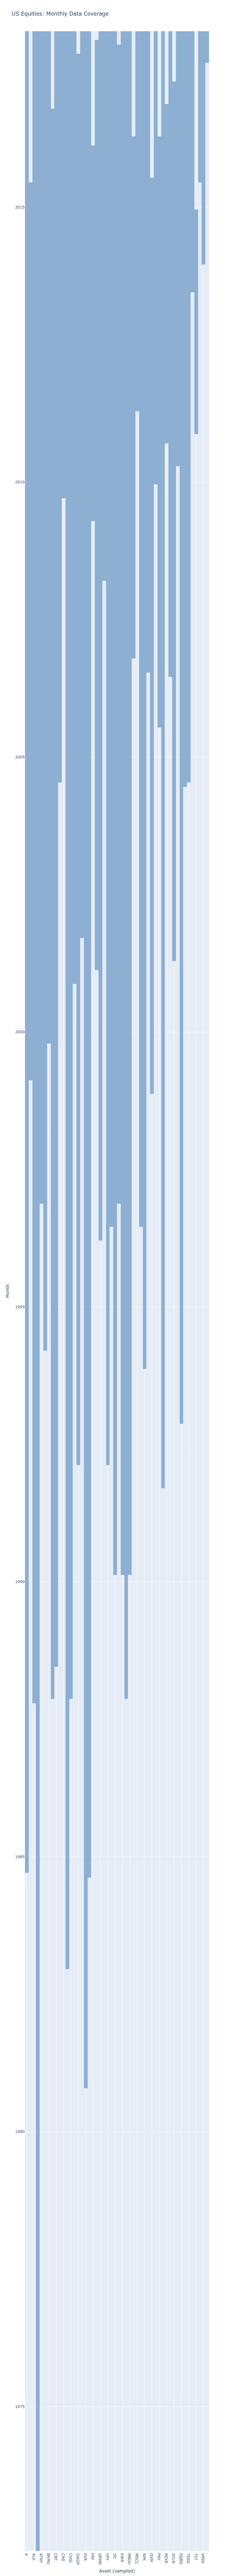

In [22]:
if us_equities is not None:
    fig = coverage_heatmap(
        us_equities,
        time_col="timestamp",
        symbol_col="symbol",
        value_col="close",
        title="US Equities: Monthly Data Coverage",
        max_symbols=50,
    )
    fig.update_layout(
        xaxis_title="Asset (sampled)",
        yaxis_title="Month",
    )
    fig.show()

The diagonal coverage pattern reflects the survivorship-free nature of this
panel: assets enter and exit the dataset as they are listed and delisted.
Vertical bands of missing data correspond to exchange closures or data-vendor
gaps. These coverage patterns inform the missing-data strategy discussed
in Section 7.1.

### 3.3 Crypto Perpetuals

24/7 trading with 8-hour funding settlement cycles. Bars should
align exactly to 00:00, 08:00, 16:00 UTC.

In [23]:
crypto_perps = load_dataset_safely(DATASET_REGISTRY["crypto_perps"]["loader"])

if crypto_perps is not None:
    config = DATASET_REGISTRY["crypto_perps"]
    crypto_perps = ensure_symbol_alias(crypto_perps)
    crypto_perps = filter_from_start(crypto_perps, "timestamp", CRYPTO_START_DATE)

    print(f"Loaded {len(crypto_perps):,} rows, {crypto_perps['symbol'].n_unique()} symbols")

    idx_check = check_index_integrity(crypto_perps, config["time_col"], config["symbol_col"])
    cov_report = coverage_report(
        crypto_perps,
        config["time_col"],
        config["symbol_col"],
        config["price_cols"],
    )
    hours = crypto_perps["timestamp"].dt.hour()
    aligned = hours.is_in([0, 8, 16]).all()

    print(f"Index Integrity: {'PASSED' if idx_check['passed'] else 'FAILED'}")
    print(f"Coverage: {cov_report['overall_coverage_pct']}%")
    print(f"8-hour alignment: {'PASSED' if aligned else 'FAILED'}")

    diagnostic_results["crypto_perps"] = {
        "index": idx_check,
        "coverage": cov_report,
        "aligned_8h": aligned,
    }

Loaded 97,717 rows, 19 symbols
Index Integrity: PASSED
Coverage: 100.0%
8-hour alignment: PASSED


### 3.4 Crypto Premium Index

Premium index for funding arbitrage strategies. Same 8-hour frequency
as perpetuals; values represent the basis between spot and futures.

In [24]:
crypto_premium = load_dataset_safely(DATASET_REGISTRY["crypto_premium"]["loader"])

if crypto_premium is not None:
    config = DATASET_REGISTRY["crypto_premium"]
    crypto_premium = ensure_symbol_alias(crypto_premium)
    crypto_premium = filter_from_start(crypto_premium, "timestamp", CRYPTO_START_DATE)

    print(f"Loaded {len(crypto_premium):,} rows, {crypto_premium['symbol'].n_unique()} symbols")

    idx_check = check_index_integrity(crypto_premium, config["time_col"], config["symbol_col"])
    dist = distribution_summary(crypto_premium, config["price_cols"])
    print(f"Index Integrity: {'PASSED' if idx_check['passed'] else 'FAILED'}")
    display(dist)

    diagnostic_results["crypto_premium"] = {"index": idx_check}

Loaded 97,239 rows, 19 symbols
Index Integrity: PASSED


field,count,null_pct,mean,std,min,q25,median,q75,max,skew,kurtosis,n_extreme,pct_extreme
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""premium_index_open""",97239,0.0,-0.000134,0.001132,-0.197132,-0.00051,-0.000211,0.000011,0.014835,-91.2579,14519.8581,67,0.0689
"""premium_index_high""",97239,0.0,0.002014,0.00396,-0.067634,0.00058,0.001196,0.002321,0.190143,17.0755,519.7054,404,0.4155
"""premium_index_low""",97239,0.0,-0.002529,0.005268,-0.295013,-0.002565,-0.001788,-0.001231,0.00178,-22.5528,803.4417,370,0.3805
"""premium_index_close""",97239,0.0,-0.00014,0.001107,-0.191547,-0.000518,-0.000222,0.000013,0.012701,-95.7368,15647.869,63,0.0648


Both crypto datasets pass integrity checks. The 24/7 schedule means no
weekend gaps to worry about, but delisting events mid-panel (coins removed
from the exchange) can create sudden coverage drops.

### 3.5 CME Futures

Session-aligned daily bars with roll continuity across contract months.

In [25]:
cme_futures = load_dataset_safely(DATASET_REGISTRY["cme_futures"]["loader"])

if cme_futures is not None:
    config = DATASET_REGISTRY["cme_futures"]
    cme_futures = filter_from_start(cme_futures, "session_date", CME_FUTURES_START_DATE)

    products = cme_futures["product"].unique().sort().to_list()
    print(f"Loaded {len(cme_futures):,} rows, {len(products)} products")
    print(f"Products: {', '.join(products)}")

    idx_check = check_index_integrity(cme_futures, config["time_col"], config["symbol_col"])
    cov_by_product = (
        cme_futures.group_by("product")
        .agg(
            pl.len().alias("n_rows"),
            pl.col("adj_close").is_null().sum().alias("n_null_close"),
        )
        .sort("product")
    )
    print(f"Index Integrity: {'PASSED' if idx_check['passed'] else 'FAILED'}")
    display(cov_by_product)

    diagnostic_results["cme_futures"] = {"index": idx_check, "n_products": len(products)}

Loaded 83,955 rows, 30 products
Products: 6A, 6B, 6C, 6E, 6J, 6S, CL, ES, GC, GF, HE, HG, HO, LE, NG, NQ, PL, RB, RTY, SI, YM, ZB, ZC, ZF, ZL, ZM, ZN, ZS, ZT, ZW
Index Integrity: PASSED


product,n_rows,n_null_close
str,u32,u32
"""6A""",2841,0
"""6B""",2841,0
"""6C""",2841,0
"""6E""",2841,0
"""6J""",2841,0
…,…,…
"""ZM""",2766,0
"""ZN""",2839,0
"""ZS""",2766,0


### 3.6 FX Pairs

4-hour bars with expected weekend gaps (market closes Friday 17:00 EST,
reopens Sunday 17:00 EST).

In [26]:
fx_pairs = load_dataset_safely(DATASET_REGISTRY["fx_pairs"]["loader"])

if fx_pairs is not None:
    config = DATASET_REGISTRY["fx_pairs"]
    fx_pairs = ensure_symbol_alias(fx_pairs)
    fx_pairs = filter_from_start(fx_pairs, "timestamp", FX_START_DATE)

    print(f"Loaded {len(fx_pairs):,} rows, {fx_pairs['symbol'].n_unique()} pairs")

    idx_check = check_index_integrity(fx_pairs, config["time_col"], config["symbol_col"])
    # Polars dt.weekday() is ISO: Monday=1 ... Saturday=6, Sunday=7. The FX week
    # reopens Sunday 17:00 EST, which lands at 21:00-22:00 UTC across daylight
    # saving, so Sunday bars at or after 21:00 UTC are the legitimate weekly
    # reopen. Saturday bars and Sunday-daytime bars are the true anomalies.
    FX_REOPEN_HOUR_UTC = 21
    fx_pairs_with_weekday = fx_pairs.with_columns(
        weekday=pl.col("timestamp").dt.weekday(),
        hour=pl.col("timestamp").dt.hour(),
    )
    weekend_data = fx_pairs_with_weekday.filter(pl.col("weekday").is_in([6, 7]))
    reopen_bars = weekend_data.filter(
        (pl.col("weekday") == 7) & (pl.col("hour") >= FX_REOPEN_HOUR_UTC)
    )
    anomalous_weekend = weekend_data.filter(
        (pl.col("weekday") == 6) | (pl.col("hour") < FX_REOPEN_HOUR_UTC)
    )
    cov_report = coverage_report(
        fx_pairs,
        config["time_col"],
        config["symbol_col"],
        config["price_cols"],
    )

    print(f"Index Integrity: {'PASSED' if idx_check['passed'] else 'FAILED'}")
    print(
        f"Weekend bars: {len(weekend_data)} "
        f"({len(reopen_bars)} Sunday reopen, expected; "
        f"{len(anomalous_weekend)} anomalous)"
    )
    print(f"Coverage: {cov_report['overall_coverage_pct']}%")

    diagnostic_results["fx_pairs"] = {
        "index": idx_check,
        "coverage": cov_report,
        "weekend_data": len(weekend_data),
        "reopen_bars": len(reopen_bars),
        "anomalous_weekend": len(anomalous_weekend),
    }

Loaded 342,308 rows, 20 pairs


Index Integrity: PASSED
Weekend bars: 11344 (11339 Sunday reopen, expected; 5 anomalous)
Coverage: 100.0%


FX trades continuously from the Sunday 17:00 EST reopen to the Friday close, so
Sunday bars at or after 21:00 UTC are expected market data. Saturday bars and
Sunday-daytime bars fall outside the trading week and are the genuine anomalies
to filter.

### 3.7 Firm Characteristics

Chen-Pelger-Zhu academic monthly panel with 46 pre-computed characteristics
(plus `ret`, `timestamp`, and a `split` indicator). Coverage is engineered
upstream: rows that fail the source paper's data-availability rules are
dropped before the panel is published, so the columns themselves arrive
dense — but the *firm-month* footprint shrinks substantially relative to a
raw CRSP–Compustat join.

In [27]:
firm_char = load_dataset_safely(DATASET_REGISTRY["firm_characteristics"]["loader"])

if firm_char is not None:
    config = DATASET_REGISTRY["firm_characteristics"]
    firm_char = filter_from_start(firm_char, "timestamp", FIRM_CHARACTERISTICS_START_DATE)

    n_dates = firm_char["timestamp"].n_unique()
    print(f"Loaded {len(firm_char):,} rows, {n_dates} months, {len(firm_char.columns)} columns")

    idx_check = {"passed": True, "note": "No symbol column (cross-sectional dataset)"}

    # Sort columns alphabetically before slicing for reproducibility
    char_cols = sorted(c for c in firm_char.columns if c not in ["timestamp", "split", "ret"])[:10]
    cov_report = coverage_report(firm_char, config["time_col"], None, char_cols)
    print(f"Coverage (sample of 10 chars): {cov_report['overall_coverage_pct']}%")
    for col, stats in cov_report["worst_columns"][:5]:
        print(f"  {col}: {stats['pct_null']:.1f}% null")

    diagnostic_results["firm_characteristics"] = {
        "index": idx_check,
        "coverage": cov_report,
        "n_characteristics": len(char_cols),
    }

Loaded 804,530 rows, 324 months, 49 columns


Coverage (sample of 10 chars): 100.0%
  A2ME: 0.0% null
  AC: 0.0% null
  AT: 0.0% null
  ATO: 0.0% null
  BEME: 0.0% null


The 10 sampled characteristics show 100% column-level coverage because the
upstream filter only retains firm-months with valid characteristic vectors.
The cost of that filter is in the row count: many small-cap firm-months are
excluded entirely, which is the right framing for §7.1's discussion of
"missing due to observed coverage rules". Downstream notebooks should not
attempt to reconstruct dropped rows; treat the panel as the authors' own
coverage rule applied at source.

## 4. Summary Dashboard

Comparative view across all datasets.

In [28]:
def rag_status(
    passed: bool | None, warning_threshold: float | None = None, value: float | None = None
) -> str:
    """Convert pass/fail to RAG status."""
    if passed is None:
        return "N/A"
    if passed:
        if warning_threshold is not None and value is not None and value < warning_threshold:
            return "WARN"
        return "OK"
    return "FAIL"

In [29]:
summary_rows = []

for name, results in diagnostic_results.items():
    row = {"Dataset": name}

    if "index" in results:
        row["Index"] = rag_status(results["index"]["passed"])
    else:
        row["Index"] = "N/A"

    if "duplicates" in results:
        row["Duplicates"] = rag_status(results["duplicates"]["passed"])
    else:
        row["Duplicates"] = "N/A"

    if "coverage" in results:
        cov_pct = results["coverage"]["overall_coverage_pct"]
        passed = cov_pct >= 95
        row["Coverage"] = f"{rag_status(passed, 99, cov_pct)} ({cov_pct}%)"
    else:
        row["Coverage"] = "N/A"

    if "outliers" in results:
        row["Outliers"] = rag_status(results["outliers"]["passed"])
    else:
        row["Outliers"] = "N/A"

    summary_rows.append(row)

summary_df = pl.DataFrame(summary_rows)
summary_df

Dataset,Index,Duplicates,Coverage,Outliers
str,str,str,str,str
"""etfs""","""OK""","""OK""","""OK (100.0%)""","""OK"""
"""us_equities""","""OK""","""OK""","""OK (100.0%)""","""FAIL"""
"""crypto_perps""","""OK""","""N/A""","""OK (100.0%)""","""N/A"""
"""crypto_premium""","""OK""","""N/A""","""N/A""","""N/A"""
"""cme_futures""","""OK""","""N/A""","""N/A""","""N/A"""
"""fx_pairs""","""OK""","""N/A""","""OK (100.0%)""","""N/A"""
"""firm_characteristics""","""OK""","""N/A""","""OK (100.0%)""","""N/A"""


All datasets pass index integrity. Coverage is high for market data (ETFs,
crypto, futures, FX). Firm characteristics show full coverage for the sampled
columns, though sparsity increases for less common characteristics.
US Equities has outlier flags (price spikes) that `02_preprocessing_pipeline`
addresses with domain filters and spike detection.

## 5. Normality Testing

The **Jarque-Bera test** jointly tests whether skewness and kurtosis match
a normal distribution. Financial returns almost always reject normality
due to fat tails and asymmetric distributions.

In [30]:
from ml4t.diagnostic.evaluation.distribution.tests import jarque_bera_test

if "etfs" in diagnostic_results:
    etfs_returns = (
        etfs.sort(["symbol", "timestamp"])
        .with_columns(pl.col("close").pct_change().over("symbol").alias("returns"))
        .filter(pl.col("returns").is_not_null() & pl.col("returns").is_finite())
    )

    spy_returns = etfs_returns.filter(pl.col("symbol") == "SPY")["returns"].to_numpy()
    jb_result = jarque_bera_test(spy_returns)

    print("Jarque-Bera Normality Test (SPY Daily Returns)")
    print(f"  Statistic:       {jb_result.statistic:.1f}")
    print(f"  P-value:         {jb_result.p_value:.2e}")
    print(f"  Skewness:        {jb_result.skewness:.3f}")
    print(f"  Excess Kurtosis: {jb_result.excess_kurtosis:.3f}")
    print(f"  Normal:          {jb_result.is_normal}")

Jarque-Bera Normality Test (SPY Daily Returns)
  Statistic:       23068.0
  P-value:         0.00e+00
  Skewness:        -0.312
  Excess Kurtosis: 14.164
  Normal:          False


SPY daily returns strongly reject normality ($p \approx 0$), driven by
excess kurtosis (fat tails). This confirms that robust scaling and
winsorization — not standard z-scoring — are appropriate for financial
returns. See `02_preprocessing_pipeline` for winsorization in practice.

### 5.1 Stationarity Quick Check

Prices are non-stationary (they trend); returns are typically stationary.
This validates using returns, not prices, as ML features and labels.
Stationarity testing is covered formally in Chapter 9.

In [31]:
from ml4t.diagnostic.evaluation.stationarity import analyze_stationarity

if "etfs" in diagnostic_results:
    spy_prices = etfs.filter(pl.col("symbol") == "SPY").sort("timestamp")["close"].to_numpy()

    price_stat = analyze_stationarity(spy_prices)
    return_stat = analyze_stationarity(spy_returns)

    print(f"SPY Prices  - Consensus: {price_stat.consensus}")
    print(f"SPY Returns - Consensus: {return_stat.consensus}")

SPY Prices  - Consensus: strong_nonstationary
SPY Returns - Consensus: strong_stationary


/home/stefan/ml4t/code/.venv/lib/python3.14/site-packages/ml4t/diagnostic/evaluation/stationarity/kpss_test.py:269: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(arr, regression=regression, nlags=nlags_param)
/home/stefan/ml4t/code/.venv/lib/python3.14/site-packages/ml4t/diagnostic/evaluation/stationarity/kpss_test.py:269: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(arr, regression=regression, nlags=nlags_param)


Prices are non-stationary (unit root), returns are stationary — the
expected result. This validates the standard practice of using returns
(or differences) rather than levels as model inputs. Chapter 9 covers
formal time series analysis including ADF, KPSS, and Phillips-Perron tests.

## 6. Key Findings

Based on the diagnostic survey, the datasets fall into two groups:

**Ready for direct use** (no structural cleaning needed):
- **ETFs** — complete OHLCV coverage; outlier flags reflect Yahoo adjustment artifacts.
- **Crypto perpetuals and premium** — complete coverage, 8-hour-aligned timestamps.
- **CME futures** — session-aligned bars across 30 products with no null closes.
- **Firm Characteristics** — column-level coverage is complete by construction;
  downstream models inherit the source paper's coverage rule.

**Require active preprocessing** (see `02_preprocessing_pipeline`):
1. **US Equities** — penny-stock filter (1.4% of rows below $1), extreme-return
   handling (837 rows above 100% daily moves), and 2,739 price-spike bars.
2. **FX Pairs** — of 11,344 weekend timestamps, 11,339 are legitimate Sunday
   reopen bars (at or after 21:00 UTC) that belong in the panel; only 5
   Saturday or Sunday-daytime bars are anomalies to filter before the
   spot-vs-forward analytics in §7.2.

The next notebook applies these cleaning steps and demonstrates split-aware
preprocessing to prevent information leakage.

## Key Takeaways

1. **Index integrity** is fundamental — time monotonicity and uniqueness must pass
2. **Coverage varies by dataset** — firm characteristics has natural sparsity; OHLCV should be complete
3. **Domain violations** (negative prices/volume) indicate data quality issues
4. **Extreme returns** in US equities often signal corporate actions (splits, delistings)
5. **Calendar alignment** matters for FX (weekends) and crypto (24/7)

**Next**: See `02_preprocessing_pipeline` for cleaning and split-aware preprocessing.
**Book**: Section 7.1 discusses why data quality determines model quality.